Example 1: Import Libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

Example 2: Line Plot (Matplotlib)

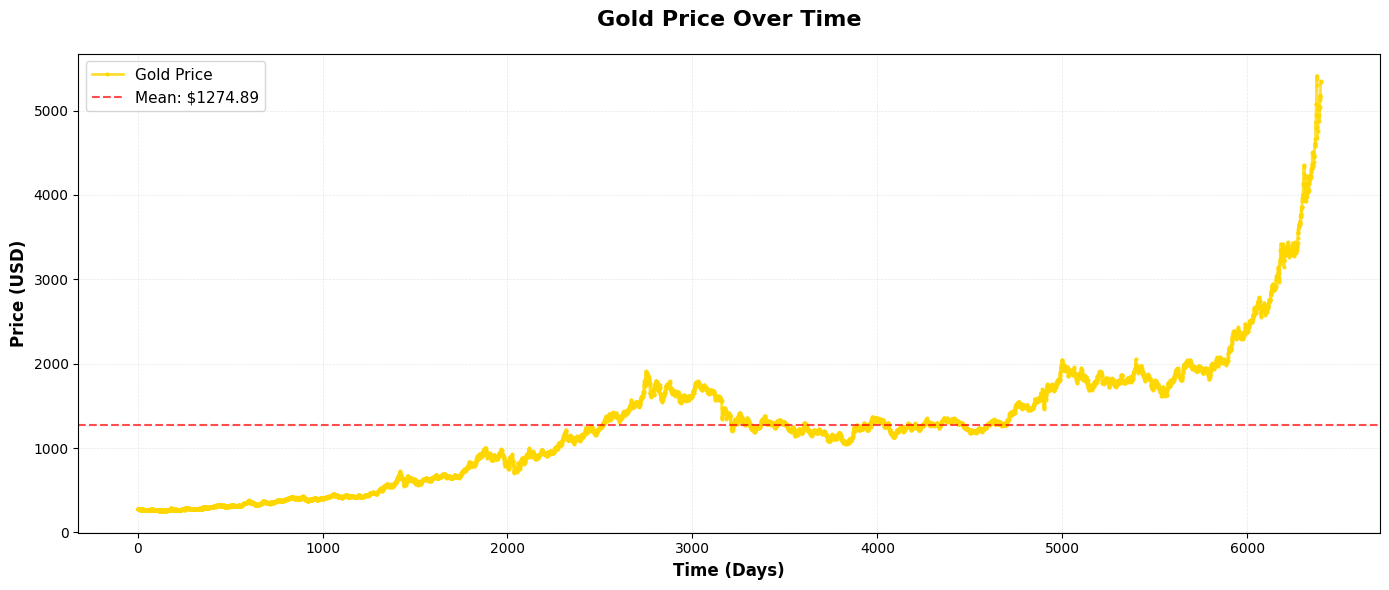

In [26]:
# Enhanced line chart with professional styling
data = pd.read_csv("datasets/goldprice.csv")

# Create figure with larger size
plt.figure(figsize=(14, 6))

# Plot with styling
plt.plot(data["Open"], linewidth=2, color='#FFD700', marker='o', markersize=2, alpha=0.8, label='Gold Price')

# Add labels and title
plt.title("Gold Price Over Time", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Time (Days)", fontsize=12, fontweight='bold')
plt.ylabel("Price (USD)", fontsize=12, fontweight='bold')

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# Add some statistics
mean_price = data["Open"].mean()
plt.axhline(y=mean_price, color='r', linestyle='--', label=f'Mean: ${mean_price:.2f}', alpha=0.7)

# Add legend
plt.legend(loc='best', fontsize=11)

# Tight layout for better spacing
plt.tight_layout()
plt.show()

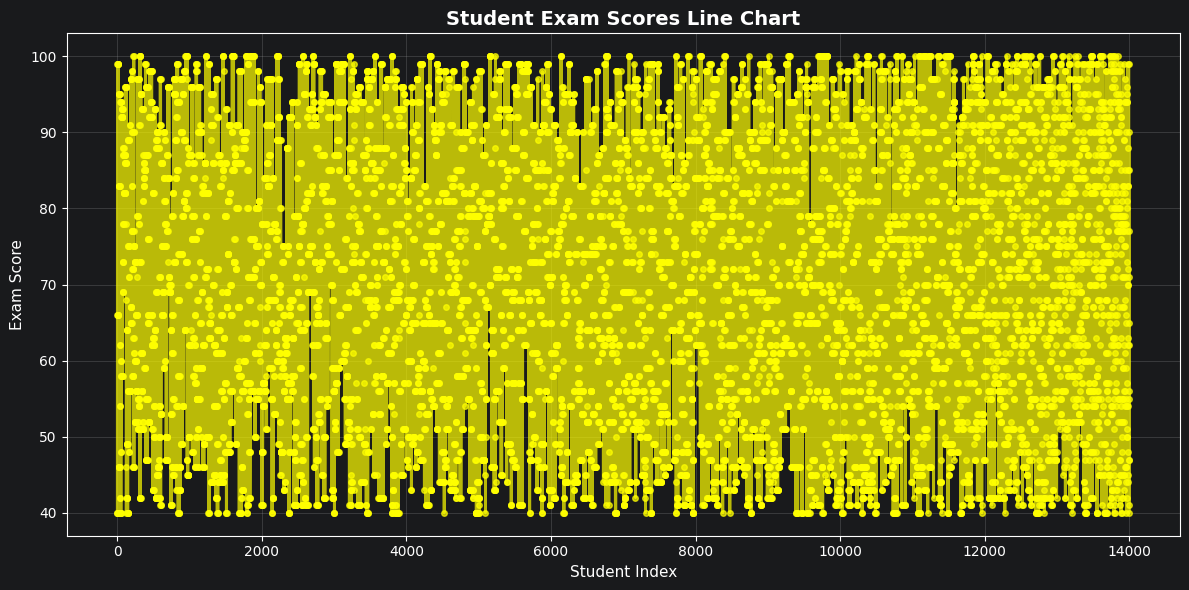

In [4]:
# Line chart using actual dataset
student_data = pd.read_csv("datasets/student_performance.csv")

plt.figure(figsize=(12, 6))
x_range = range(len(student_data))
plt.plot(x_range, student_data["ExamScore"], marker='o', linewidth=2, markersize=4, color='yellow', alpha=0.7)
plt.title("Student Exam Scores Line Chart", fontsize=14, fontweight='bold')
plt.xlabel("Student Index", fontsize=11)
plt.ylabel("Exam Score", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Example 3: Bar Chart

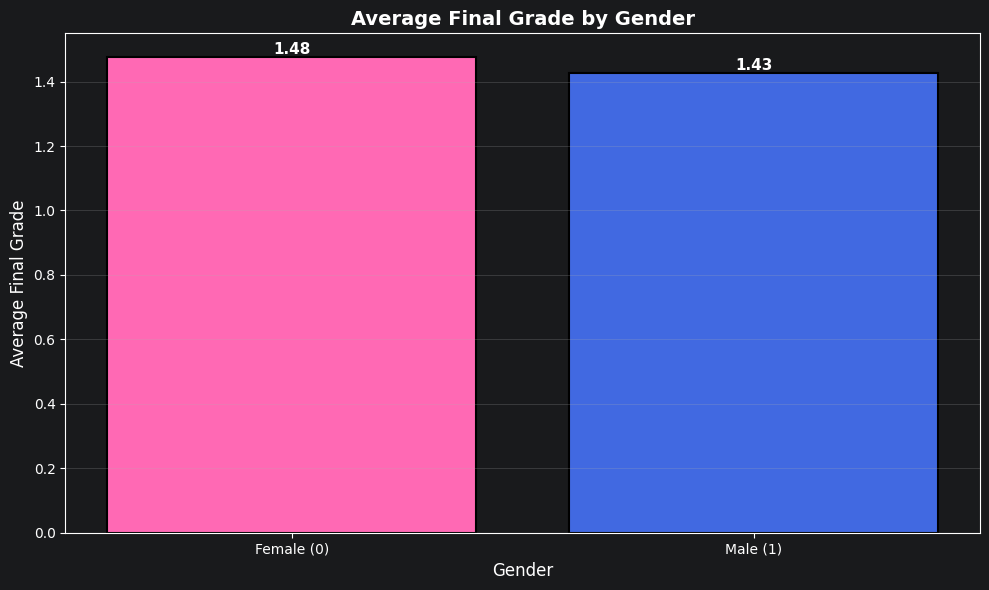

In [5]:
# Bar chart using student performance data
student_data = pd.read_csv("datasets/student_performance.csv")

# Calculate average grades by gender
avg_by_gender = student_data.groupby('Gender')['FinalGrade'].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(['Female (0)', 'Male (1)'], avg_by_gender.values, color=['#FF69B4', '#4169E1'], edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Average Final Grade by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Average Final Grade", fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Example 4: Histogram

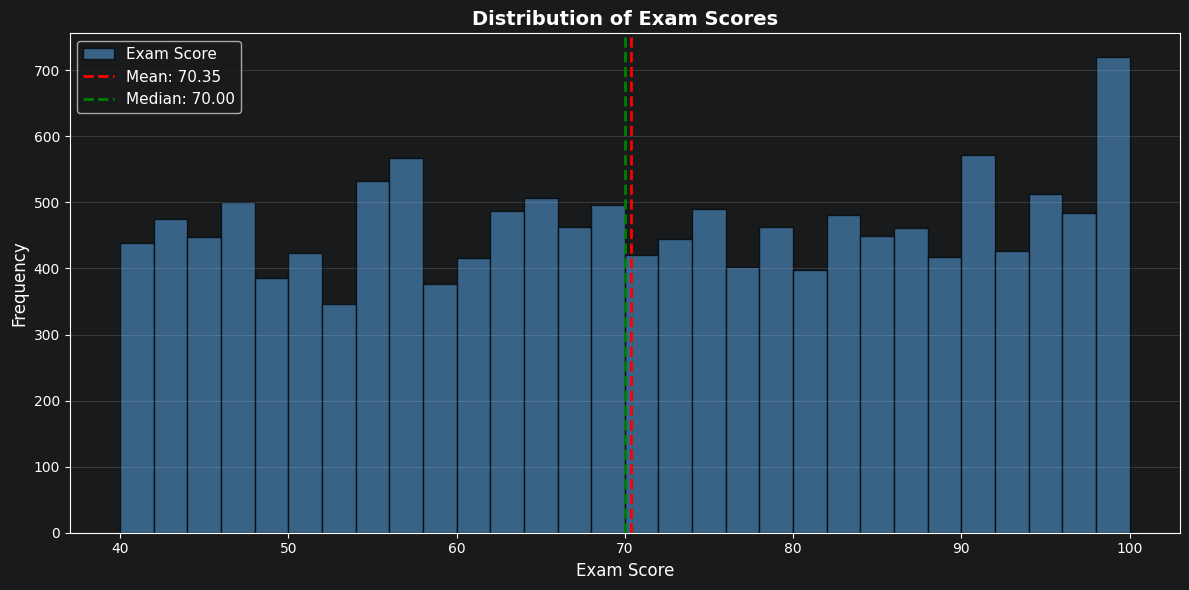

In [6]:
# Histogram using student performance data
student_data = pd.read_csv("datasets/student_performance.csv")

plt.figure(figsize=(12, 6))

# Plot histogram of exam scores
plt.hist(student_data['ExamScore'], bins=30, color='steelblue', edgecolor='black', alpha=0.7, label='Exam Score')
plt.axvline(student_data['ExamScore'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {student_data["ExamScore"].mean():.2f}')
plt.axvline(student_data['ExamScore'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {student_data["ExamScore"].median():.2f}')

plt.title("Distribution of Exam Scores", fontsize=14, fontweight='bold')
plt.xlabel("Exam Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Example 5: Scatter Plot

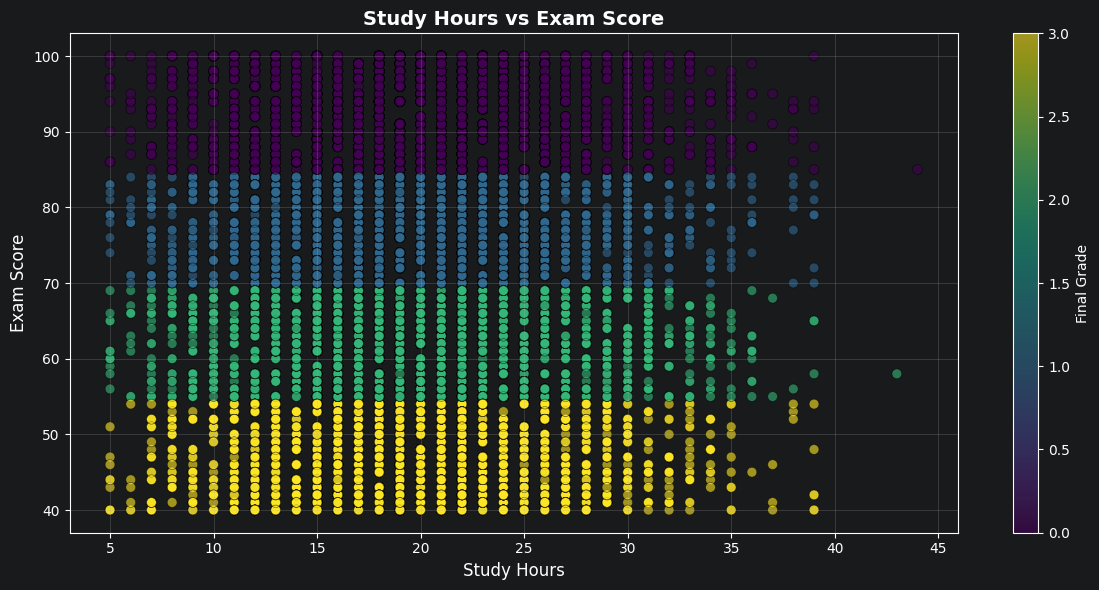

In [7]:
# Scatter plot using student performance data
student_data = pd.read_csv("datasets/student_performance.csv")

plt.figure(figsize=(12, 6))
scatter = plt.scatter(student_data['StudyHours'], student_data['ExamScore'],
                     c=student_data['FinalGrade'], cmap='viridis',
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, label='Final Grade')
plt.title("Study Hours vs Exam Score", fontsize=14, fontweight='bold')
plt.xlabel("Study Hours", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Example 6: Seaborn Distribution Plot (histplot)

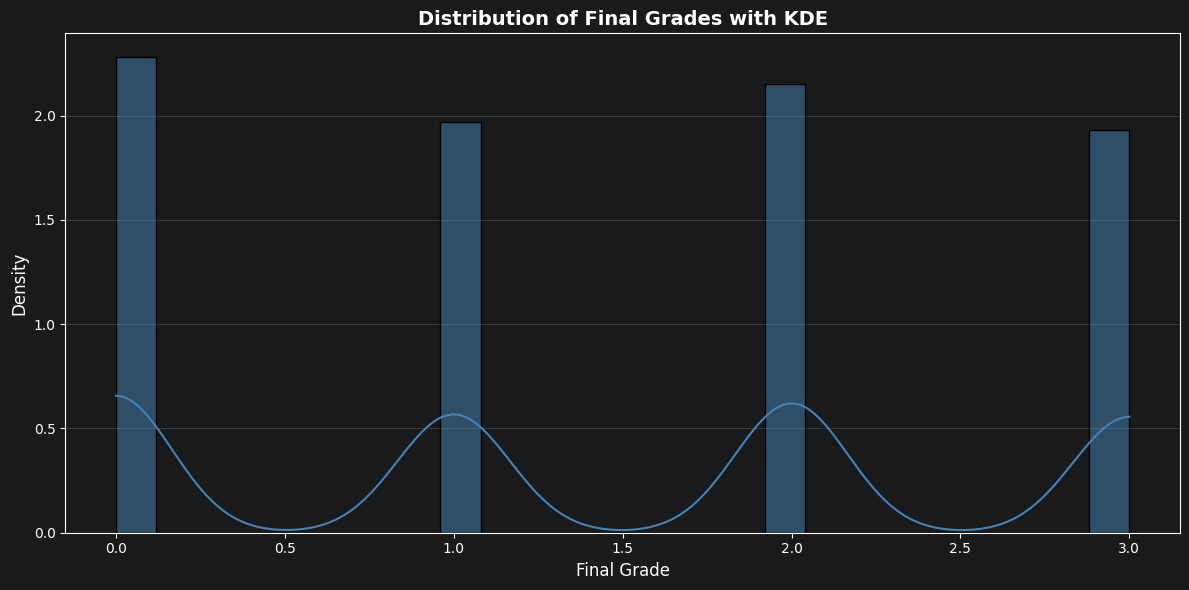

In [8]:
# Histogram plot with seaborn using actual data
student_data = pd.read_csv("datasets/student_performance.csv")

plt.figure(figsize=(12, 6))
sns.histplot(data=student_data, x='FinalGrade', kde=True, bins=25,
             color='steelblue', edgecolor='black', stat='density')
plt.title("Distribution of Final Grades with KDE", fontsize=14, fontweight='bold')
plt.xlabel("Final Grade", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Example 7: Seaborn Heatmap (Correlation)

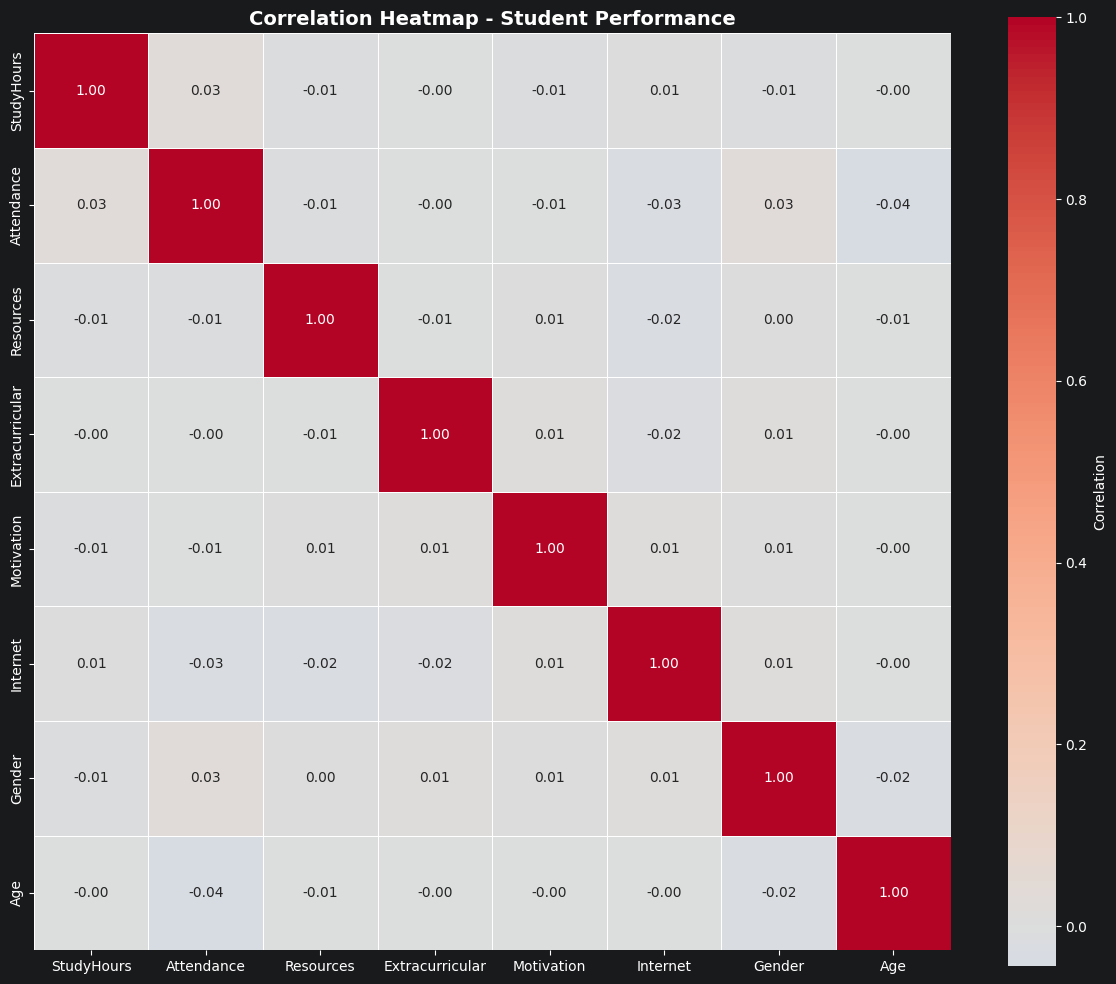

In [9]:
# Heatmap showing correlation matrix of student performance data
student_data = pd.read_csv("datasets/student_performance.csv")

# Select numeric columns for correlation
numeric_data = student_data.select_dtypes(include=['number']).iloc[:, :8]
corr = numeric_data.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlation'}, linewidths=0.5, square=True)
plt.title("Correlation Heatmap - Student Performance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Example 8: Confusion Matrix to be CONt.

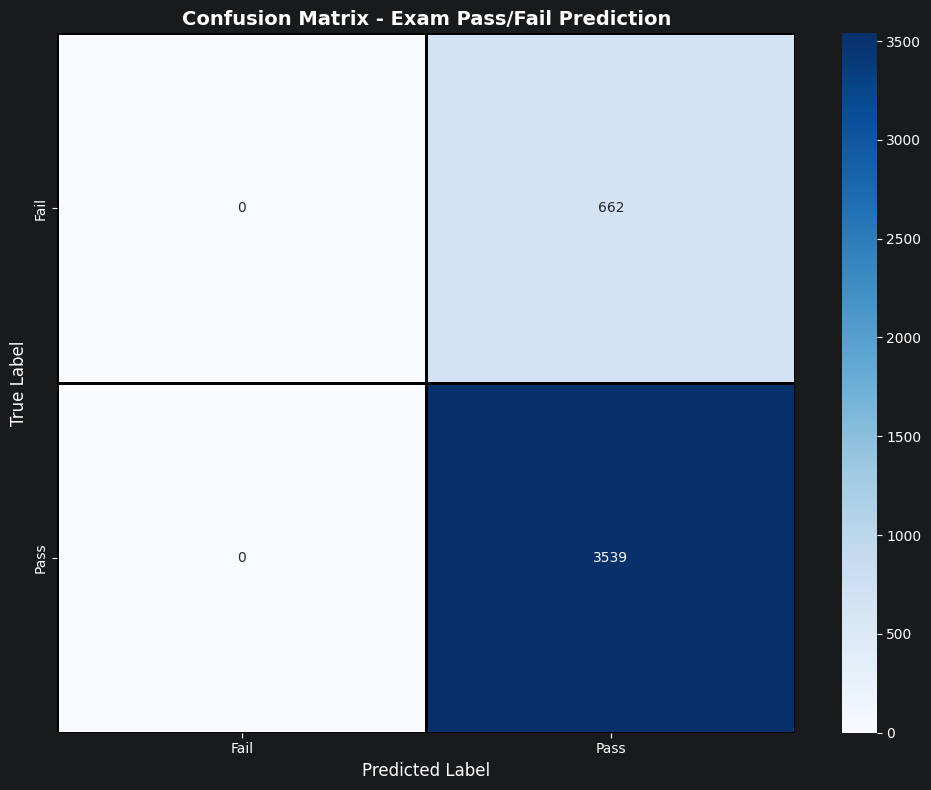

True Negatives: 0
False Positives: 662
False Negatives: 0
True Positives: 3539
Accuracy: 0.8424


In [10]:
# Confusion matrix for classification predictions
student_data = pd.read_csv("datasets/student_performance.csv")

# Create a binary classification: Pass (1) if ExamScore >= 50, else Fail (0)
y_true = (student_data['ExamScore'] >= 50).astype(int)

# Use StudyHours and Attendance as features for prediction
X = student_data[['StudyHours', 'Attendance']]

# Split data and train a simple classifier
X_train, X_test, y_train, y_test = train_test_split(X, y_true, test_size=0.3, random_state=42)
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'],
            linewidths=2, linecolor='black')
plt.title("Confusion Matrix - Exam Pass/Fail Prediction", fontsize=14, fontweight='bold')
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.show()

# Print accuracy metrics
print(f"True Negatives: {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives: {cm[1, 1]}")
print(f"Accuracy: {(cm[0, 0] + cm[1, 1]) / cm.sum():.4f}")

Example 9: Simple Heatmap (Data Matrix)

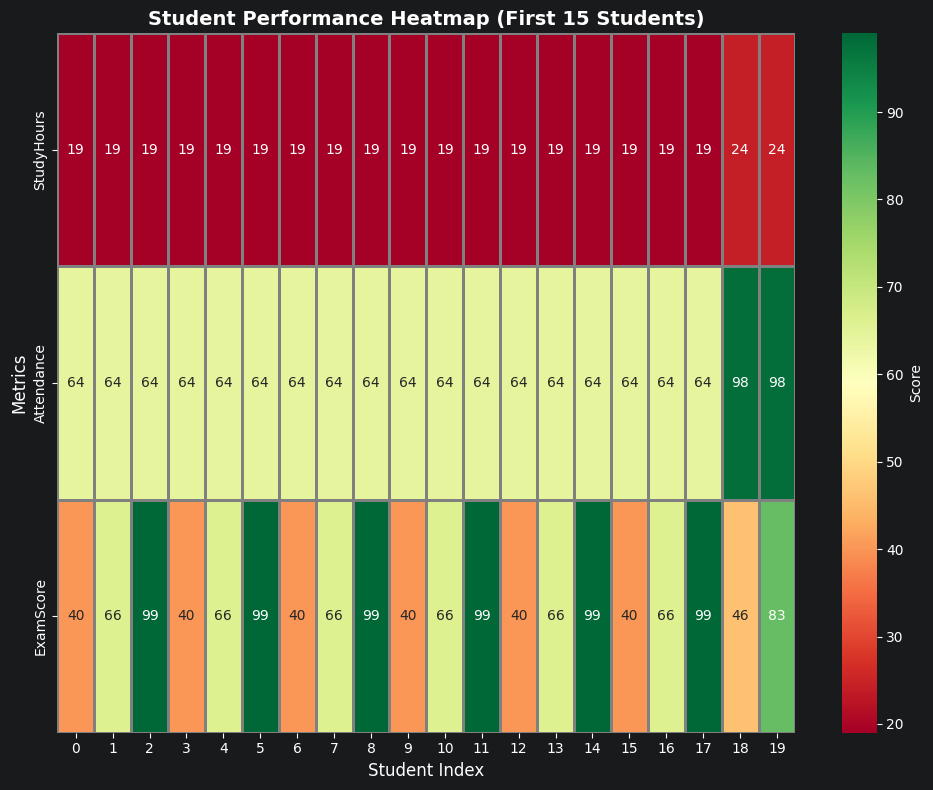

In [13]:
# Create a simple heatmap of numeric data
student_data = pd.read_csv("datasets/student_performance.csv")

# Select specific numeric columns and take a sample
sample_data = student_data[['StudyHours', 'Attendance', 'ExamScore']].head(20)

plt.figure(figsize=(10, 8))
sns.heatmap(sample_data.T, annot=True, fmt='.0f', cmap='RdYlGn',
            cbar_kws={'label': 'Score'}, linewidths=1, linecolor='gray')
plt.title("Student Performance Heatmap (First 15 Students)", fontsize=14, fontweight='bold')
plt.xlabel("Student Index", fontsize=12)
plt.ylabel("Metrics", fontsize=12)
plt.tight_layout()
plt.show()

Example 10: Advanced Heatmap with Clustering

<Figure size 1000x1000 with 0 Axes>

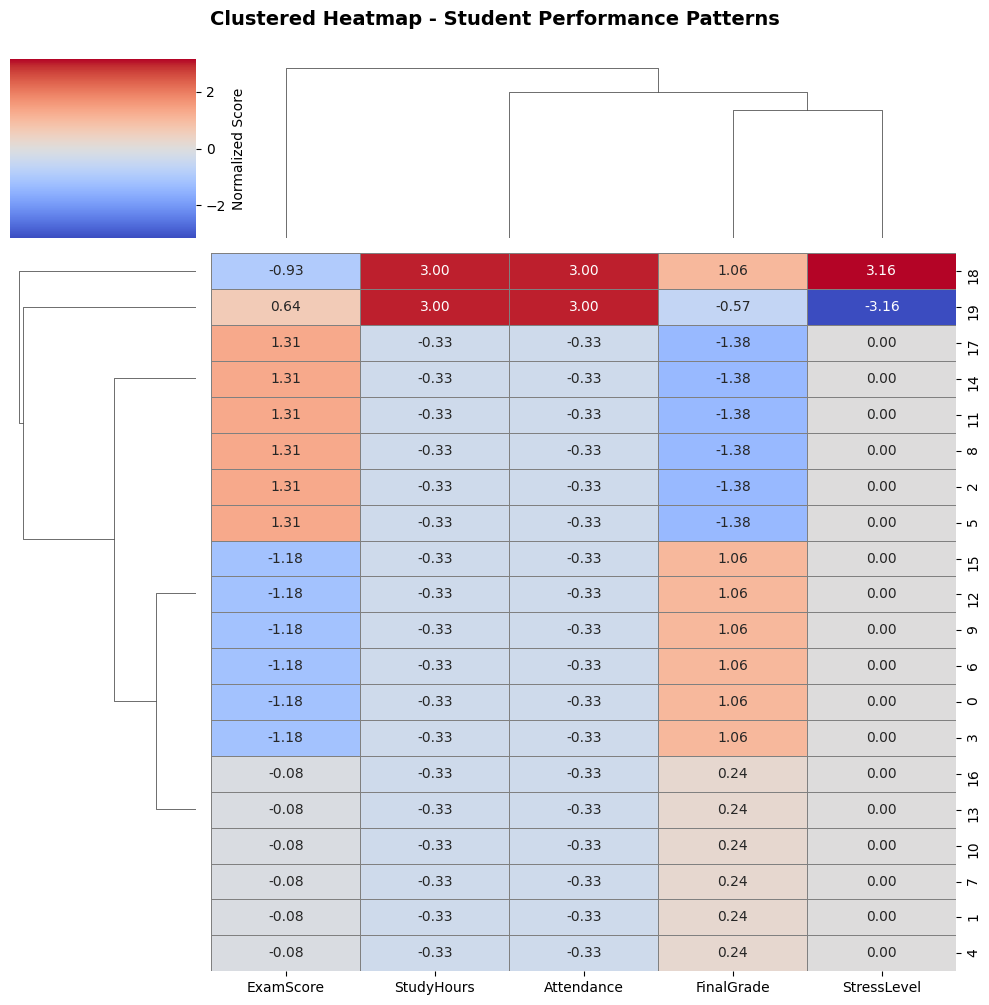

In [15]:
# Heatmap with clustering to show patterns
student_data = pd.read_csv("datasets/student_performance.csv")

# Select numeric columns and normalize
numeric_cols = ['StudyHours', 'Attendance', 'ExamScore', 'FinalGrade', 'StressLevel']
sample_data = student_data[numeric_cols].head(20)

# Normalize data for better visualization
scaler = StandardScaler()
normalized_data = pd.DataFrame(scaler.fit_transform(sample_data), columns=numeric_cols)

plt.figure(figsize=(10, 10))
sns.clustermap(normalized_data, cmap='coolwarm', center=0,
               annot=True, fmt='.2f', linewidths=0.5, linecolor='gray',
               cbar_kws={'label': 'Normalized Score'})
plt.suptitle("Clustered Heatmap - Student Performance Patterns", fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

Example 11: Scatter Plot with Hue (Hue Map)

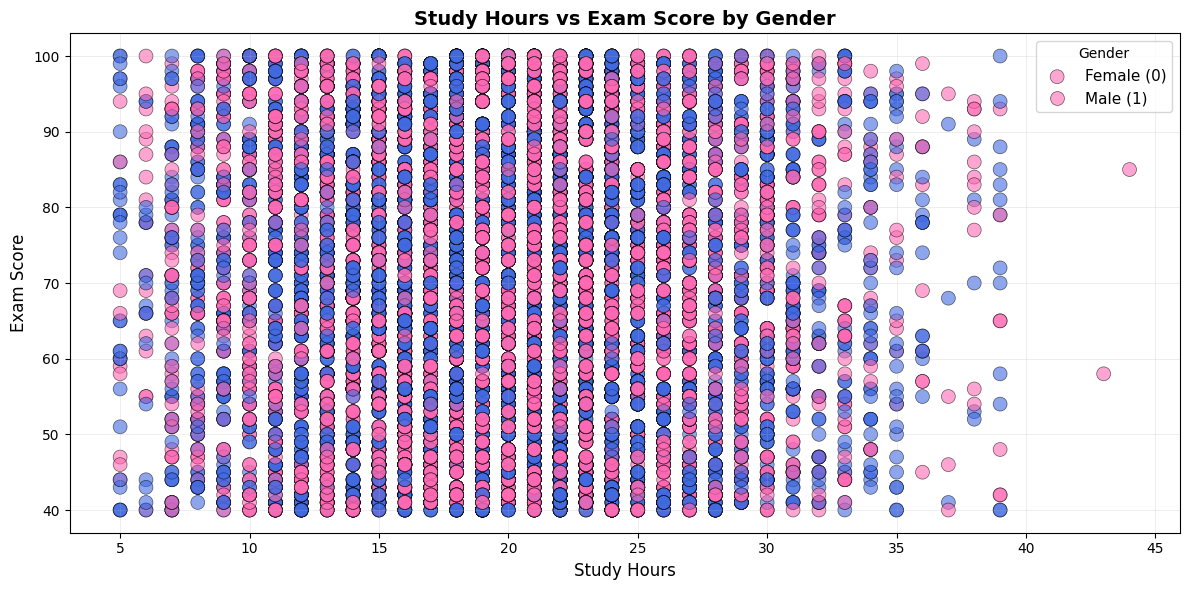

In [16]:
# Scatter plot with hue parameter for categorical variable
student_data = pd.read_csv("datasets/student_performance.csv")

plt.figure(figsize=(12, 6))
sns.scatterplot(data=student_data, x='StudyHours', y='ExamScore',
                hue='Gender', palette=['#FF69B4', '#4169E1'],
                s=100, alpha=0.6, edgecolor='black', linewidth=0.5)
plt.title("Study Hours vs Exam Score by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Study Hours", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.legend(title='Gender', labels=['Female (0)', 'Male (1)'], loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Example 12: Pairplot (Seaborn)

<Figure size 1000x1000 with 0 Axes>

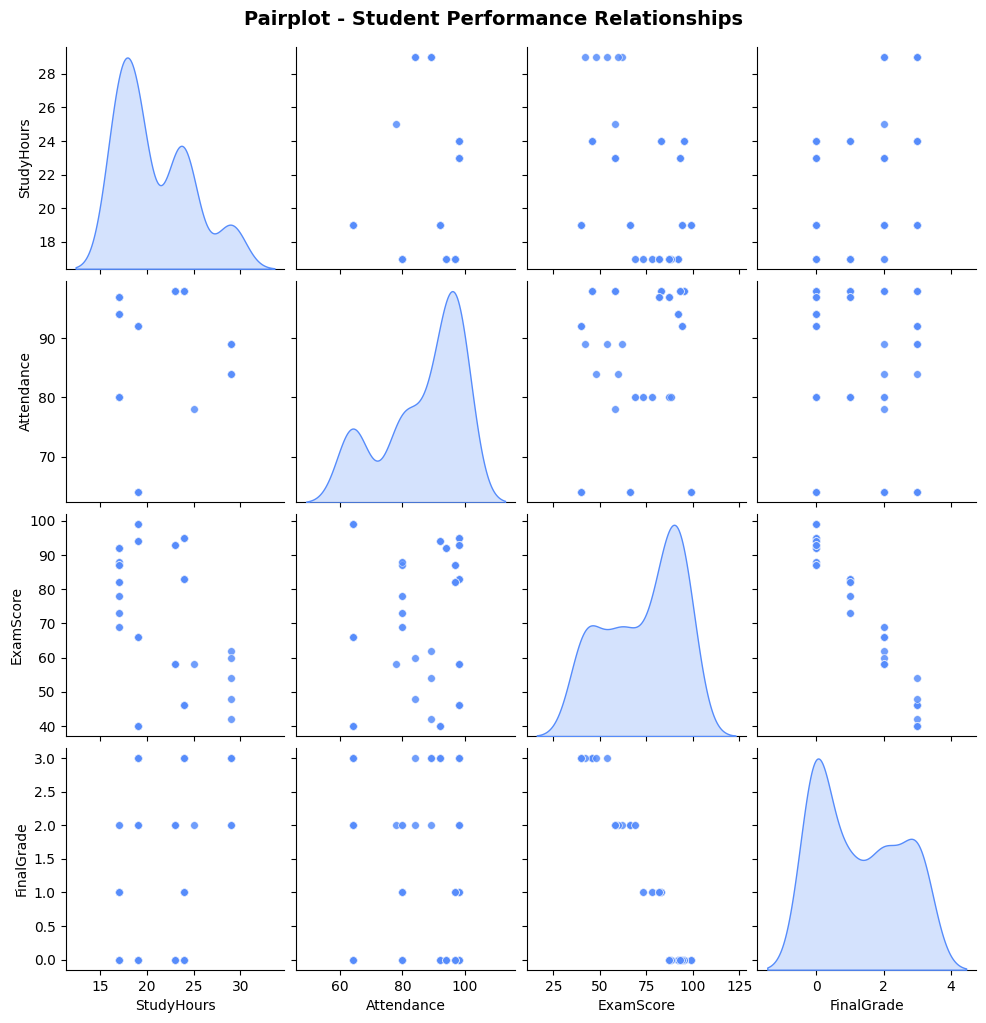

In [17]:
# Pairplot showing relationships between multiple variables
student_data = pd.read_csv("datasets/student_performance.csv")

# Select key numeric columns for pairplot
pairplot_data = student_data[['StudyHours', 'Attendance', 'ExamScore', 'FinalGrade']].head(100)

plt.figure(figsize=(10, 10))
sns.pairplot(pairplot_data, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30})
plt.suptitle("Pairplot - Student Performance Relationships", fontsize=14, fontweight='bold', y=1.02)
plt.show()

Example 13: Box Plot

/var/folders/pj/k78tnlfd70x2r6r2m3x__yq40000gn/T/ipykernel_79094/1813001029.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=student_data, x='Gender', y='ExamScore', palette=['#FF69B4', '#4169E1'])


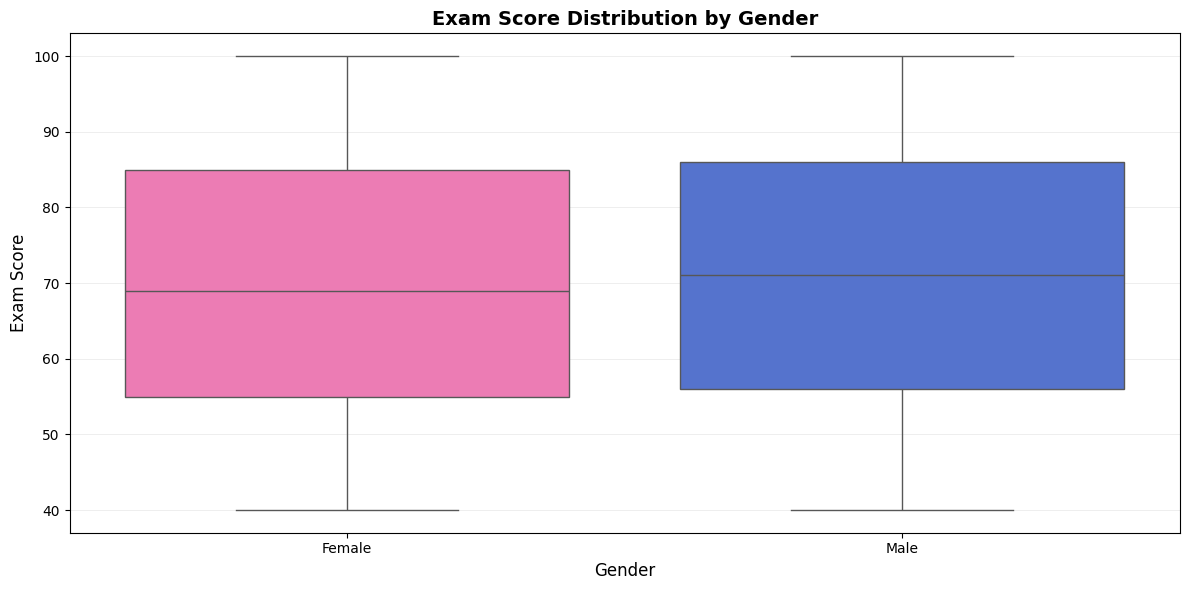

In [18]:
# Box plot to show distribution and outliers
student_data = pd.read_csv("datasets/student_performance.csv")

plt.figure(figsize=(12, 6))
sns.boxplot(data=student_data, x='Gender', y='ExamScore', palette=['#FF69B4', '#4169E1'])
plt.title("Exam Score Distribution by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.xticks([0, 1], ['Female', 'Male'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Example 14: Violin Plot

/var/folders/pj/k78tnlfd70x2r6r2m3x__yq40000gn/T/ipykernel_79094/2232596907.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=student_data, x='Gender', y='FinalGrade', palette=['#FF69B4', '#4169E1'], inner='quartile')


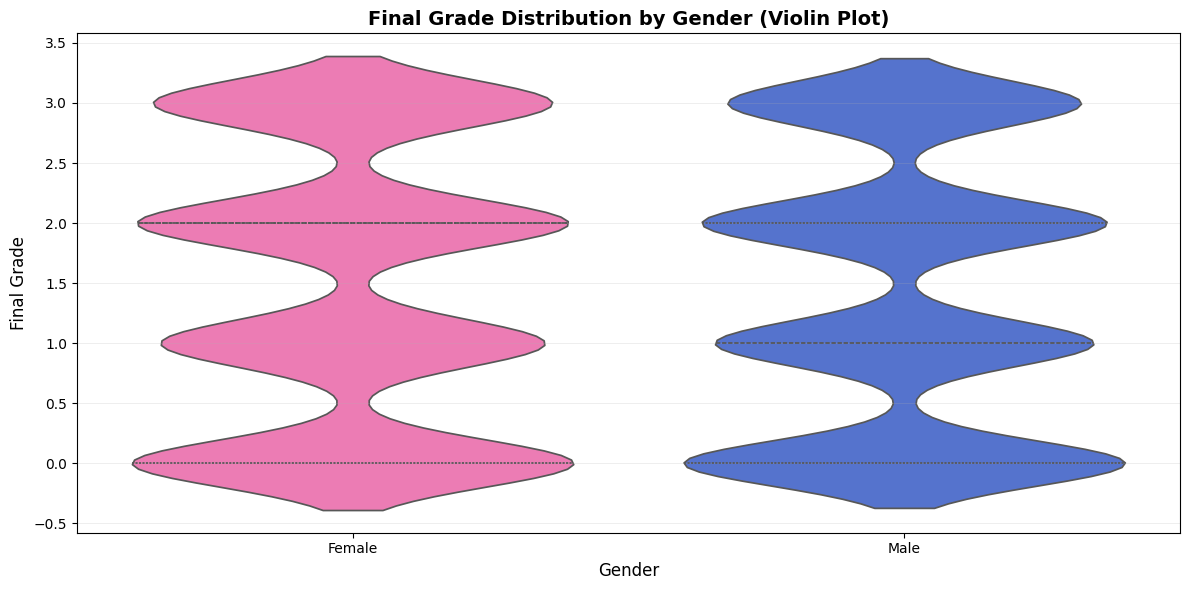

In [19]:
# Violin plot combining box plot and density plot
student_data = pd.read_csv("datasets/student_performance.csv")

plt.figure(figsize=(12, 6))
sns.violinplot(data=student_data, x='Gender', y='FinalGrade', palette=['#FF69B4', '#4169E1'], inner='quartile')
plt.title("Final Grade Distribution by Gender (Violin Plot)", fontsize=14, fontweight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Final Grade", fontsize=12)
plt.xticks([0, 1], ['Female', 'Male'])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Example 15: Pie Chart

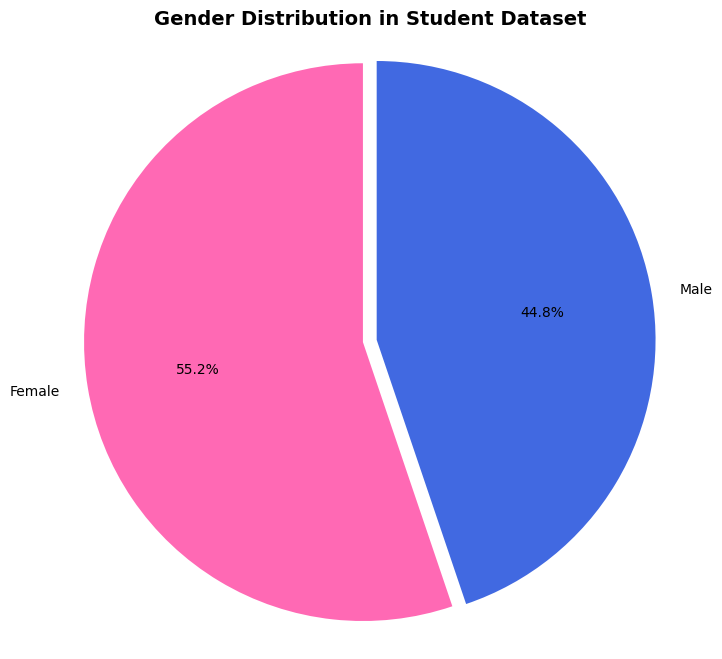

In [20]:
# Pie chart showing gender distribution
student_data = pd.read_csv("datasets/student_performance.csv")

gender_counts = student_data['Gender'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(gender_counts.values, labels=['Female', 'Male'], autopct='%1.1f%%',
        colors=['#FF69B4', '#4169E1'], startangle=90, explode=[0.05, 0])
plt.title("Gender Distribution in Student Dataset", fontsize=14, fontweight='bold')
plt.axis('equal')
plt.show()

Example 16: Area Chart

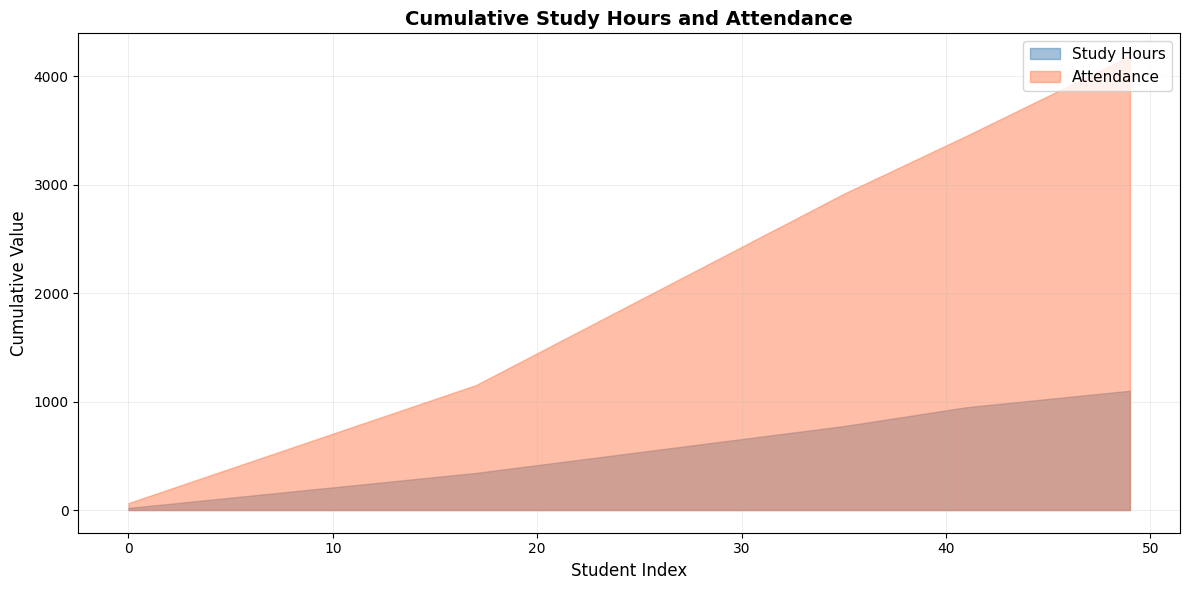

In [21]:
# Area chart showing cumulative performance
student_data = pd.read_csv("datasets/student_performance.csv")

# Create cumulative data
cumulative_data = student_data[['StudyHours', 'Attendance']].head(50).cumsum()

plt.figure(figsize=(12, 6))
plt.fill_between(range(len(cumulative_data)), cumulative_data['StudyHours'],
                 alpha=0.5, color='steelblue', label='Study Hours')
plt.fill_between(range(len(cumulative_data)), cumulative_data['Attendance'],
                 alpha=0.5, color='coral', label='Attendance')
plt.title("Cumulative Study Hours and Attendance", fontsize=14, fontweight='bold')
plt.xlabel("Student Index", fontsize=12)
plt.ylabel("Cumulative Value", fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Example 17: 3D Scatter Plot

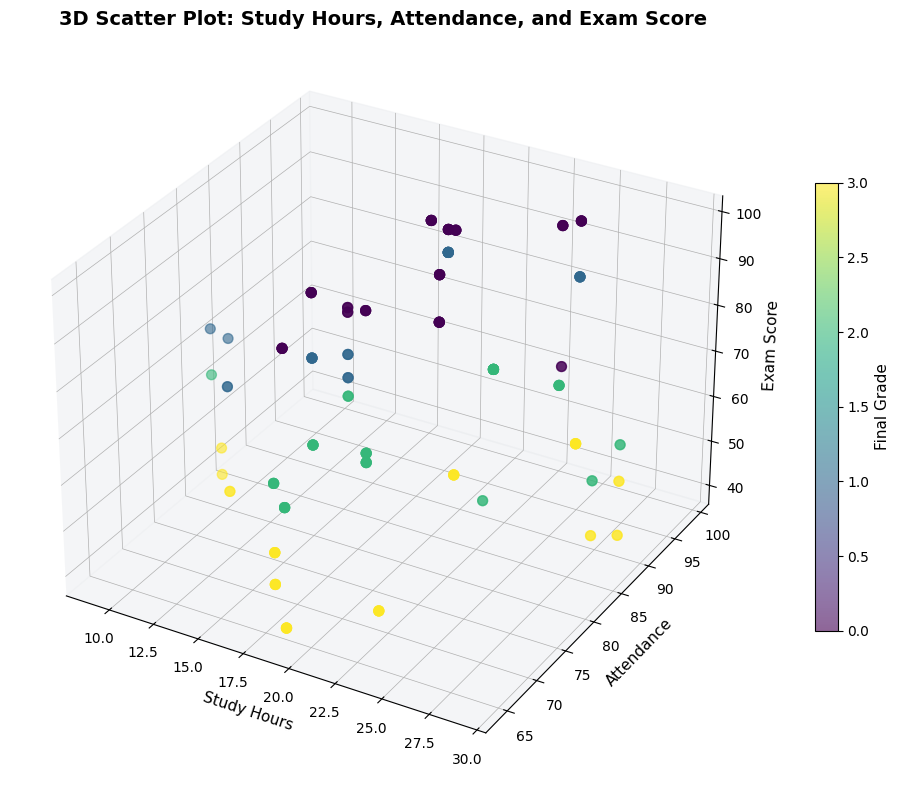

In [22]:
# 3D scatter plot for three variables
from mpl_toolkits.mplot3d import Axes3D

student_data = pd.read_csv("datasets/student_performance.csv")

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(student_data['StudyHours'].head(200),
                    student_data['Attendance'].head(200),
                    student_data['ExamScore'].head(200),
                    c=student_data['FinalGrade'].head(200),
                    cmap='viridis', s=50, alpha=0.6)

ax.set_xlabel('Study Hours', fontsize=11)
ax.set_ylabel('Attendance', fontsize=11)
ax.set_zlabel('Exam Score', fontsize=11)
ax.set_title('3D Scatter Plot: Study Hours, Attendance, and Exam Score', fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
cbar.set_label('Final Grade', fontsize=11)

plt.tight_layout()
plt.show()

Example 18: Bubble Chart

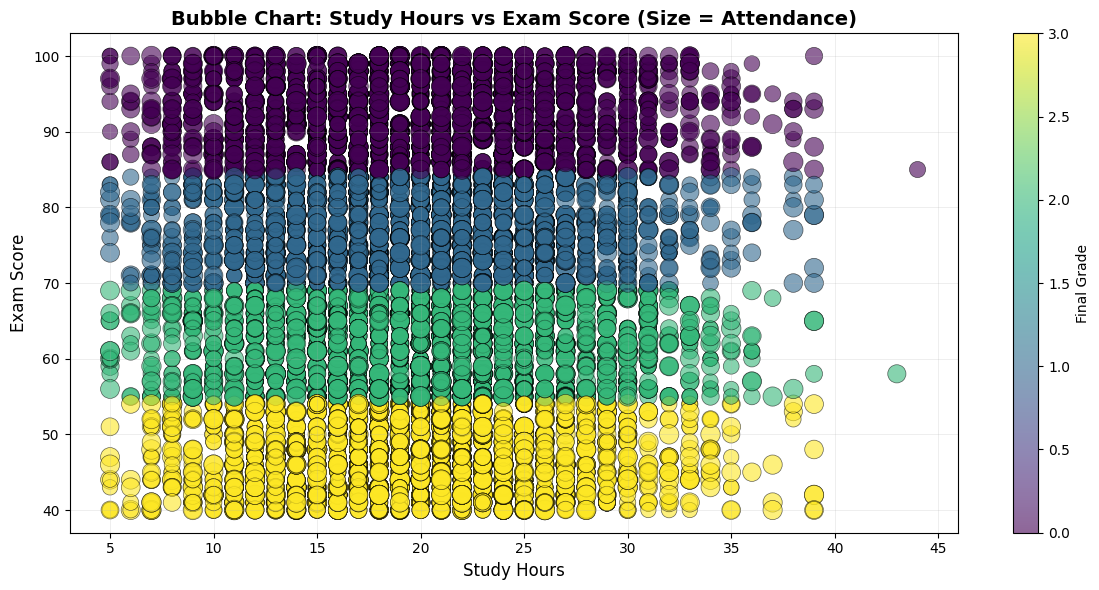

In [23]:
# Bubble chart with size representing another variable
student_data = pd.read_csv("datasets/student_performance.csv")

plt.figure(figsize=(12, 6))
bubble = plt.scatter(student_data['StudyHours'], student_data['ExamScore'],
                    s=student_data['Attendance']*2,  # Size based on attendance
                    c=student_data['FinalGrade'], cmap='viridis',
                    alpha=0.6, edgecolors='black', linewidth=0.5)

plt.colorbar(bubble, label='Final Grade')
plt.title("Bubble Chart: Study Hours vs Exam Score (Size = Attendance)", fontsize=14, fontweight='bold')
plt.xlabel("Study Hours", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Example 19: Hexbin Plot

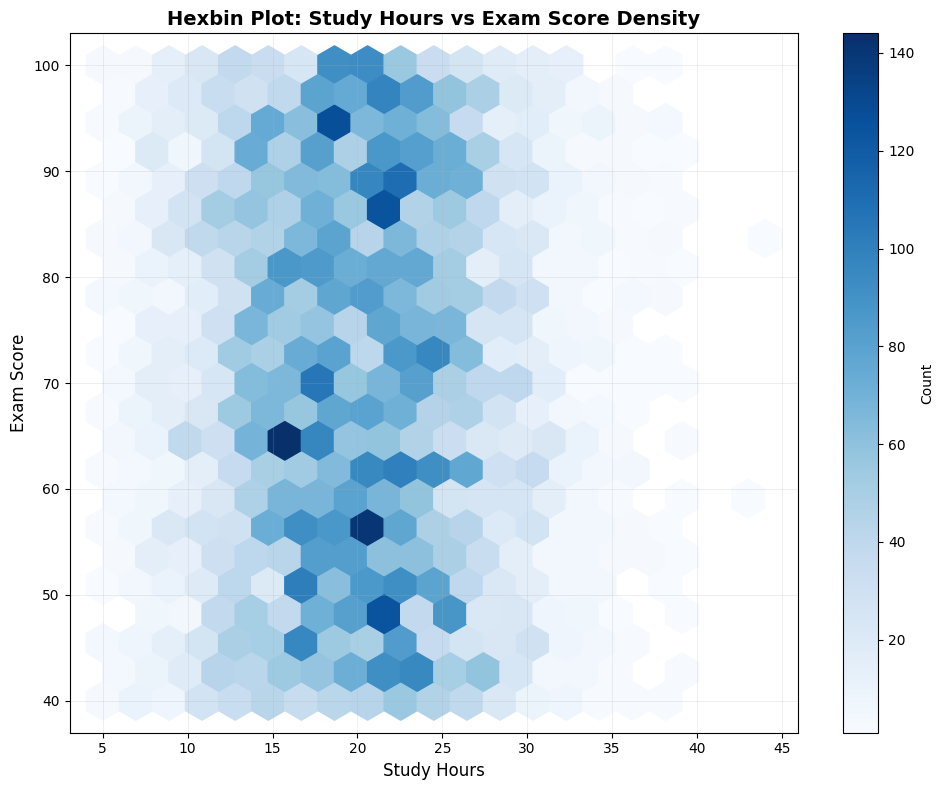

In [24]:
# Hexbin plot for dense scatter data
student_data = pd.read_csv("datasets/student_performance.csv")

plt.figure(figsize=(10, 8))
hb = plt.hexbin(student_data['StudyHours'], student_data['ExamScore'],
                gridsize=20, cmap='Blues', mincnt=1)
plt.colorbar(hb, label='Count')
plt.title("Hexbin Plot: Study Hours vs Exam Score Density", fontsize=14, fontweight='bold')
plt.xlabel("Study Hours", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Example 20: Contour Plot

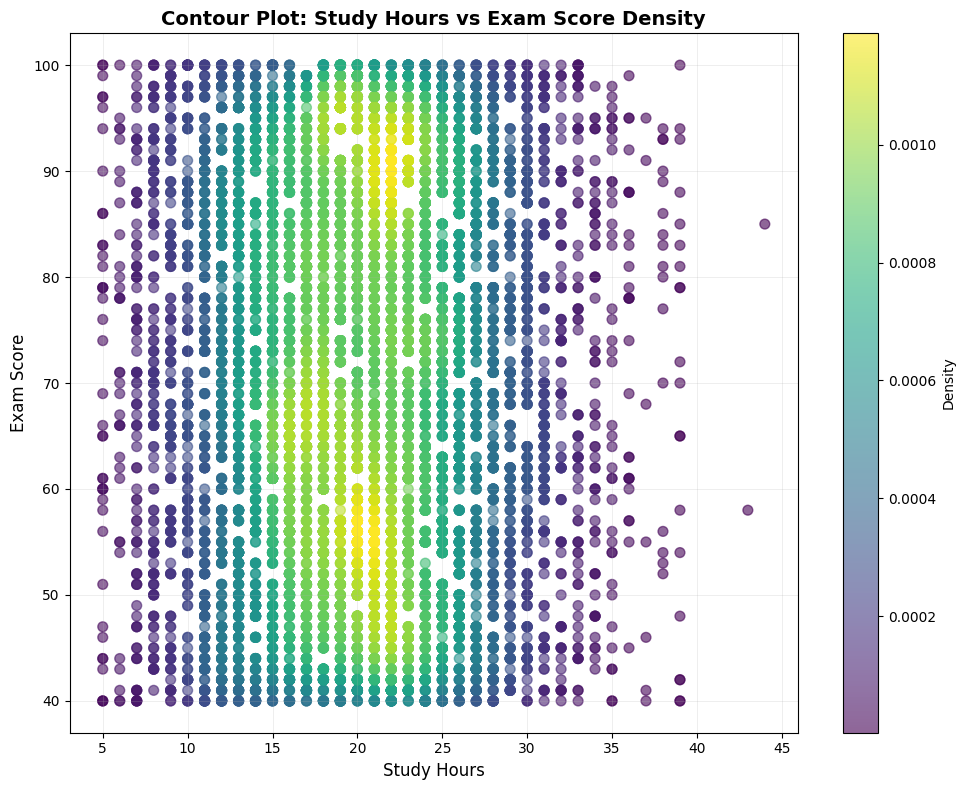

In [25]:
# Contour plot showing density
from scipy.stats import gaussian_kde

student_data = pd.read_csv("datasets/student_performance.csv")

# Calculate the point density
xy = np.vstack([student_data['StudyHours'], student_data['ExamScore']])
z = gaussian_kde(xy)(xy)

plt.figure(figsize=(10, 8))
plt.scatter(student_data['StudyHours'], student_data['ExamScore'], c=z, s=50, alpha=0.6, cmap='viridis')
plt.colorbar(label='Density')
plt.title("Contour Plot: Study Hours vs Exam Score Density", fontsize=14, fontweight='bold')
plt.xlabel("Study Hours", fontsize=12)
plt.ylabel("Exam Score", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=========================

﷿﷿﷿﷿ ASSIGNMENTS in-class

=========================

Assignment 1: Line Plot

In [ ]:
# 1. Create x = 1 to 10
# 2. Create y = x^2
# 3. Plot using line chart
x = list(range(1, 11))
y = [i**2 for i in x]

plt.figure(figsize=(10, 6))
plt.plot(x, y, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.title("Line Plot: y = x﷿﷿", fontsize=14, fontweight='bold')
plt.xlabel("X values", fontsize=12)
plt.ylabel("Y values (x﷿﷿)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Assignment 2: Histogram

In [ ]:
# 1. Generate random data (100 values)
# 2. Plot histogram
# 3. Add title
data = np.random.randn(100)

plt.figure(figsize=(10, 6))
plt.hist(data, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.title("Histogram of Random Data", fontsize=14, fontweight='bold')
plt.xlabel("Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Assignment 3: Statistics

In [ ]:
# 1. Create a list of numbers
# 2. Calculate mean and median
# 3. Print results
data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

mean = np.mean(data)
median = np.median(data)
std = np.std(data)
variance = np.var(data)

print("Data:", data)
print(f"Mean: {mean:.2f}")
print(f"Median: {median:.2f}")
print(f"Standard Deviation: {std:.2f}")
print(f"Variance: {variance:.2f}")

Assignment 4: Correlation

In [ ]:
# 1. Create a DataFrame with 2 columns
# 2. Calculate correlation
# 3. Plot heatmap
df = pd.DataFrame({
    "Study Hours": [2, 4, 6, 8, 10, 12, 14, 16, 18, 20],
    "Exam Score": [45, 55, 65, 75, 85, 88, 92, 95, 98, 100]
})

correlation = df.corr()
print("Correlation Matrix:")
print(correlation)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar=True)
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
